In [1]:
import os, shutil
import keras

Using TensorFlow backend.


In [2]:
#directory where I store the data
original_datasets_dir = 'data/train'
base_dir = 'data for Chapter 5'
os.mkdir(base_dir)

In [3]:
#Create train, test and validation folder seperately
train_dir = os.path.join(base_dir,'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir,'test')
os.mkdir(test_dir)

In [4]:
#create subfolder
train_cat_dir = os.path.join(train_dir,'cats for train')
os.mkdir(train_cat_dir)
train_dog_dir = os.path.join(train_dir,'dogs for train')
os.mkdir(train_dog_dir)

validation_cat_dir = os.path.join(validation_dir,'cats for validation')
os.mkdir(validation_cat_dir)
validation_dog_dir = os.path.join(validation_dir,'dogs for validation')
os.mkdir(validation_dog_dir)

test_cat_dir = os.path.join(test_dir,'cats for test')
os.mkdir(test_cat_dir)
test_dog_dir = os.path.join(test_dir,'dogs for test')
os.mkdir(test_dog_dir)

In [5]:
#copy the image to the folder 
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]#train sets
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(train_cat_dir, fname)
    shutil.copyfile(src, dst)
    
fnames = ['cat.{}.jpg'.format(i) for i in range(1000,1500)]#validation sets
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(validation_cat_dir, fname)
    shutil.copyfile(src, dst)
    
fnames = ['cat.{}.jpg'.format(i) for i in range(1500,2000)]#test set
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(test_cat_dir, fname)
    shutil.copyfile(src, dst)

fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]#train sets
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(train_dog_dir, fname)
    shutil.copyfile(src, dst)
    
fnames = ['dog.{}.jpg'.format(i) for i in range(1000,1500)]#validation sets
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(validation_dog_dir, fname)
    shutil.copyfile(src, dst)
    
fnames = ['dog.{}.jpg'.format(i) for i in range(1500,2000)] #test set
for fname in fnames:
    src = os.path.join(original_datasets_dir, fname)
    dst = os.path.join(test_dog_dir, fname)
    shutil.copyfile(src, dst)


In [6]:
#check how many pictures are in each train,validation and test 
print('total training cat images: ', len(os.listdir(train_cat_dir)))
print('total training dog images: ', len(os.listdir(train_dog_dir)))
print('total validation cat images: ', len(os.listdir(validation_cat_dir)))
print('total validation dog images: ', len(os.listdir(validation_dog_dir)))
print('total test cat images: ', len(os.listdir(test_cat_dir)))
print('total test dog images: ', len(os.listdir(test_dog_dir)))

total training cat images:  1000
total training dog images:  1000
total validation cat images:  500
total validation dog images:  500
total test cat images:  500
total test dog images:  500


building the network

In [7]:
#Instantiating a small convnet for dogs-vs-cat classiffication
from keras import layers
from keras import models

model = models.Sequential()
model.add(layers.Conv2D(32,(3,3), activation = 'relu',input_shape = (150,150,3)))

In [8]:
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation = 'relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation = 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))

In [9]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 34, 34, 128)       73856     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 15, 15, 128)       147584    
__________

In [10]:
#configuring the model for training
from keras import optimizers
model.compile(loss ='binary_crossentropy', optimizer = optimizers.RMSprop(lr = 1e-4), metrics = ['acc'])

Data preprocessing

In [11]:
from keras.preprocessing.image import ImageDataGenerator
#rescale all image by 1/255 (to fit learing rate)
train_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255)

In [12]:
train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [13]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


In [14]:
#fitting the model using a batch generator
history = model.fit_generator(
      train_generator,
      steps_per_epoch=100,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=50)

Epoch 1/30
100/100 [==============================] - 105s 1s/step - loss: 0.6921 - acc: 0.5345 - val_loss: 0.6810 - val_acc: 0.5750
Epoch 2/30
100/100 [==============================] - 104s 1s/step - loss: 0.6554 - acc: 0.6175 - val_loss: 0.6997 - val_acc: 0.5560
Epoch 3/30
100/100 [==============================] - 110s 1s/step - loss: 0.6087 - acc: 0.6690 - val_loss: 0.6172 - val_acc: 0.6500
Epoch 4/30
100/100 [==============================] - 108s 1s/step - loss: 0.5698 - acc: 0.7100 - val_loss: 0.6229 - val_acc: 0.6530
Epoch 5/30
100/100 [==============================] - 109s 1s/step - loss: 0.5431 - acc: 0.7270 - val_loss: 0.5851 - val_acc: 0.6910
Epoch 6/30
100/100 [==============================] - 103s 1s/step - loss: 0.5103 - acc: 0.7360 - val_loss: 0.6249 - val_acc: 0.6560
Epoch 7/30
100/100 [==============================] - 110s 1s/step - loss: 0.4875 - acc: 0.7610 - val_loss: 0.6161 - val_acc: 0.6710
Epoch 8/30
100/100 [==============================] - 112s 1s/step - 

In [15]:
#save the model
model.save('Chapter_5_build_the_network.h5')

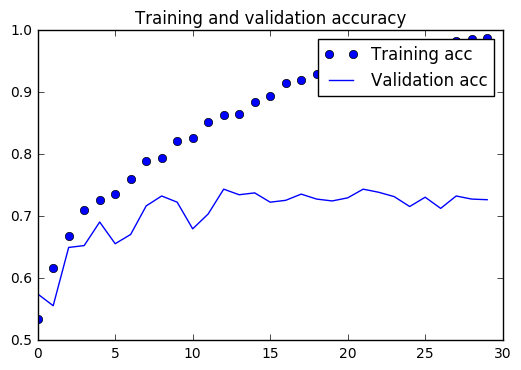

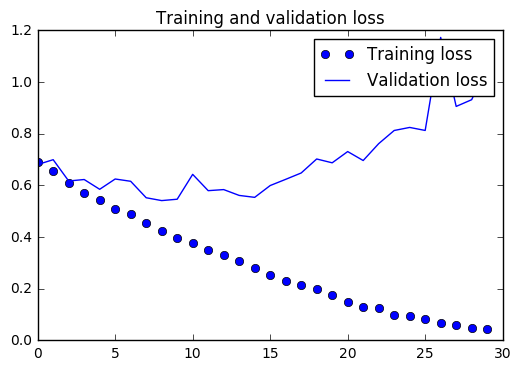

In [16]:
#display the loss and accruracy
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()